
# ML Project: Payment Default Risk Prediction

This notebook presents a complete Machine Learning pipeline to predict payment default risk using historical customer data.

---

##  Objective

Build a supervised classification model that predicts the **risk bucket** of a customer (e.g. no delay, early, medium, late, etc.) based on features such as purchase price, monthly payment, age, city, and vehicle information.

---


In [1]:

# Step 1: Import required libraries
import pandas as pd
import numpy as np
import os

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib



# Load Excel dataset from your local path
file_path = r"C:\Users\hardr\OneDrive\Pictures\Datos adjuntos\Documents\Desktop\Python_scripts\ML_RIESGO_IMPAGO\src\data_sample\CAR4CASH_DATA.xlsx"
df = pd.read_excel(file_path)

# Show first rows
df.head()


In [2]:

# Load Excel dataset (assumes file is saved locally in this path)
file_path = r"C:\Users\hardr\OneDrive\Pictures\Datos adjuntos\Documents\Desktop\Python_scripts\ML_RIESGO_IMPAGO\src\data_sample\CAR4CASH_DATA.xlsx"
df = pd.read_excel(file_path)

# Show first rows
df.head()


,ID,Tipo,Representante comercial,Precio de compra,Moneda,IVA,Precio de compra en €,Firma del contrato,Fecha del principio de contrato,Plazo mensual,...,Matrícula,F. de matriculación:,Kilómetros recorridos,Número de propietarios anteriores,Fecha de la última matriculación del vehículo,Importaciones del extranjero,Fecha de importación del extranjero,Vendido a tercero,Condición,Partner
0,7246,Contrato,"Car Service Partner Spain, S.L.",2795,EUR,0 % IVA,70350.15,Sí,2025-04-09,189,...,2143HZB,2014-08-29 00:00:00,181649,6,NaN,0,NaN,0000-00-00,Activos,google
1,7245,Contrato,"Car Service Partner Spain, S.L.",2795,EUR,0 % IVA,70350.15,Sí,2025-04-08,189,...,8581MVC,2014-05-21 00:00:00,205000,1,NaN,1,2024-09-19,0000-00-00,Activos,Web
2,7244,Contrato,"Car Service Partner Spain, S.L.",2295,EUR,0 % IVA,57765.15,Sí,2025-04-08,156,...,0511MCD,2011-05-30 00:00:00,206500,2,2024-09-02,1,2022-11-07,0000-00-00,Activos,google
3,7243,Contrato,"Car Service Partner Spain, S.L.",2295,EUR,0 % IVA,57765.15,Sí,2025-04-08,170,...,7900HFJ,2011-07-08 00:00:00,60895,4,2025-04-07,0,NaN,0000-00-00,Activos,google
4,7240,Contrato,"Car Service Partner Spain, S.L.",4295,EUR,0 % IVA,108105.15,Sí,2025-04-07,295,...,9381KWN,2019-04-29 00:00:00,166000,0,2019-04-29,0,NaN,0000-00-00,Activos,google


## Step 3: Clean column names

In [3]:

# Remove trailing spaces in column names
df.columns = df.columns.str.strip()


## Step 4: Create target variable 'Bucket'

In [4]:

def asignar_bucket(v):
    if pd.isna(v):
        return 'desconocido'
    try:
        v = int(v)
        if v >= 0:
            return 'no delay'
        elif v >= -5:
            return 'early'
        elif v >= -15:
            return 'medium'
        elif v >= -30:
            return 'late'
        elif v >= -60:
            return 'external'
        else:
            return 'realdebt'
    except:
        return 'desconocido'

df['Bucket'] = df['Vencimiento'].apply(asignar_bucket)
df = df[df['Bucket'] != 'desconocido']


## Step 5: Define features (X) and target (y)

In [5]:

X = df.drop(columns=['Vencimiento', 'Bucket'])
y = df['Bucket']


## Step 6: Preprocessing - Handle missing values and types

In [6]:

cat_features = ['Código postal', 'Ciudad', 'Marca', 'Modelo', 'Partner', 'Genero']
num_features = ['Precio de compra en €', 'Plazo mensual', 'edad']

# Convert categorical to string and fill missing
for col in cat_features:
    X[col] = X[col].fillna("missing").astype(str)

# Convert numeric to float and coerce invalid values to NaN
for col in num_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Check for missing values
print("Missing values per column:")
print(X.isnull().sum())


Missing values per column:
ID                                                   0
Tipo                                                 0
Representante comercial                              0
Precio de compra                                     0
Moneda                                               0
IVA                                                  0
Precio de compra en €                                0
Firma del contrato                                   0
Fecha del principio de contrato                      0
Plazo mensual                                        0
Plazo del IVA                                        0
Cantidad de tasa de reserva en € IVA incluido        0
Cantidad de tasa de reserva en € sin IVA             0
Fecha del plazo siguiente                           37
Precio de mercado                                    0
Cociente precio de mercado/precio de compra (%)      0
Teléfono                                             0
Correo electrónico                    

## Step 7: Create complete preprocessing + modeling pipeline

In [7]:

# Define numeric and categorical pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])


## Step 8: Train-test split and improved model setup

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])


## Step 9: Train and evaluate the model

In [9]:

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       early       0.00      0.00      0.00         6
    external       0.00      0.00      0.00        10
        late       0.00      0.00      0.00         9
      medium       0.00      0.00      0.00         6
    no delay       0.53      0.84      0.65        87
    realdebt       0.59      0.40      0.47        68

    accuracy                           0.54       186
   macro avg       0.19      0.21      0.19       186
weighted avg       0.46      0.54      0.48       186

Confusion Matrix:
[[ 0  0  0  0  4  2]
 [ 0  0  0  0  8  2]
 [ 0  0  0  0  7  2]
 [ 0  0  0  0  6  0]
 [ 0  1  0  0 73 13]
 [ 0  0  1  0 40 27]]


c:\Users\hardr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hardr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hardr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

## Step 10: Save the trained model

In [11]:

# Create models directory if it doesn't exist
os.makedirs("src/models", exist_ok=True)

# Save the model
joblib.dump(pipeline, "src/models/modelo_riesgo_impago.pkl")
print("Model saved at: src/models/modelo_riesgo_impago.pkl")


Model saved at: src/models/modelo_riesgo_impago.pkl



##  Recomendaciones de uso del modelo entrenado / Using the trained model with new data

### 🇪🇸 Español

Para utilizar este modelo entrenado con datos nuevos, es importante seguir algunas recomendaciones clave:

1. El dataset debe contener **exactamente las mismas columnas de entrada** que se usaron durante el entrenamiento:
   - `'Código postal'`
   - `'Ciudad'`
   - `'Marca'`
   - `'Modelo'`
   - `'Partner'`
   - `'Genero'`
   - `'Precio de compra en €'`
   - `'Plazo mensual'`
   - `'edad'`

2. **No debe incluir la columna `'Bucket'`**, ya que es la variable objetivo que el modelo va a predecir.

3. No hace falta escalar, codificar ni imputar datos manualmente: el modelo ya incluye todo el preprocesamiento necesario.

4. Para predecir, solo tienes que hacer:

```python
from joblib import load
modelo = load("src/models/modelo_riesgo_impago.pkl")
predicciones = modelo.predict(nuevos_datos)
```

---

### 🇬🇧 English

To use the trained model with new data, please follow these guidelines:

1. Your input data must include **exactly the same columns** used during training:
   - `'Código postal'` (Postal code)
   - `'Ciudad'` (City)
   - `'Marca'` (Car brand)
   - `'Modelo'` (Car model)
   - `'Partner'` (Partner)
   - `'Genero'` (Gender)
   - `'Precio de compra en €'` (Purchase price)
   - `'Plazo mensual'` (Monthly payment)
   - `'edad'` (Age)

2. **Do not include the `'Bucket'` column** — that is the value to be predicted.

3. There is no need to scale or encode manually: the model includes all required preprocessing.

4. Example usage:

```python
from joblib import load
model = load("src/models/modelo_riesgo_impago.pkl")
predictions = model.predict(new_data)
```


In [13]:
# ===========================================
# LOAD THE TRAINED MODEL / CARGAR EL MODELO
# ===========================================

from joblib import load

# Cargar el modelo entrenado desde archivo .pkl
# Load the trained pipeline from the .pkl file
model_path = "src/models/modelo_riesgo_impago.pkl"
modelo = load(model_path)

print(" Modelo cargado correctamente / Model loaded successfully")

# ===========================================
# PREPARAR NUEVOS DATOS PARA PREDICCIÓN
# PREPARE NEW DATA FOR PREDICTION
# ===========================================

# Este es un ejemplo con un DataFrame de nuevos clientes
# This is an example with a DataFrame of new customers

import pandas as pd

nuevo_df = pd.DataFrame([
    {
        'Código postal': '28001',
        'Ciudad': 'Madrid',
        'Marca': 'Toyota',
        'Modelo': 'Yaris',
        'Partner': 'Partner_1',
        'Genero': 'M',
        'Precio de compra en €': 12000,
        'Plazo mensual': 250,
        'edad': 35
    },
    {
        'Código postal': '08002',
        'Ciudad': 'Barcelona',
        'Marca': 'Renault',
        'Modelo': 'Clio',
        'Partner': 'Partner_2',
        'Genero': 'F',
        'Precio de compra en €': 8000,
        'Plazo mensual': 150,
        'edad': 28
    }
])

# ===========================================
# HACER PREDICCIONES / MAKE PREDICTIONS
# ===========================================

# El modelo ya contiene todo el pipeline: imputación, codificación, etc.
# The model includes all preprocessing: imputation, encoding, etc.

predicciones = modelo.predict(nuevo_df)

# Mostrar las predicciones
print(" Predicciones del modelo / Model Predictions:")
print(predicciones)

# ===========================================
# OPCIONAL: CALCULAR ACCURACY SI TENEMOS y_true
# OPTIONAL: CALCULATE ACCURACY IF WE HAVE y_true
# ===========================================

# Si conoces las etiquetas verdaderas para evaluar la precisión:
# If you know the actual labels to evaluate accuracy:

# y_true = ['early', 'no delay']  # <-- Reemplaza por los valores reales
# from sklearn.metrics import accuracy_score
# accuracy = accuracy_score(y_true, predicciones)
# print(" Accuracy:", accuracy)


 Modelo cargado correctamente / Model loaded successfully
 Predicciones del modelo / Model Predictions:
['realdebt' 'realdebt']


In [14]:
# ==================================================
# VER PROBABILIDAD POR CLASE / PREDICT CLASS PROBAS
# ==================================================

# predict_proba devuelve la probabilidad estimada para cada clase
# predict_proba returns the estimated probability for each class

probas = modelo.predict_proba(nuevo_df)

# Mostrar nombres de las clases
print("Clases del modelo / Model classes:", modelo.classes_)

# Mostrar probabilidades para cada fila
for i, fila in enumerate(probas):
    print(f"\nCliente {i+1} - Probabilidades por clase:")
    for clase, prob in zip(modelo.classes_, fila):
        print(f"{clase}: {prob:.2f}")


Clases del modelo / Model classes: ['early' 'external' 'late' 'medium' 'no delay' 'realdebt']

Cliente 1 - Probabilidades por clase:
early: 0.02
external: 0.02
late: 0.05
medium: 0.08
no delay: 0.38
realdebt: 0.45

Cliente 2 - Probabilidades por clase:
early: 0.00
external: 0.08
late: 0.01
medium: 0.00
no delay: 0.26
realdebt: 0.65



 Variables más importantes para el modelo:
                           feature  importance
1               num__Plazo mensual    0.044859
0       num__Precio de compra en €    0.040571
2                        num__edad    0.037711
1598           cat__Partner_google    0.010013
1594              cat__Partner_Web    0.009261
1606            cat__Genero_HOMBRE    0.008760
1607             cat__Genero_MUJER    0.006845
793             cat__Ciudad_Madrid    0.006796
1599  cat__Partner_lead-adtraction    0.006183
797             cat__Ciudad_Malaga    0.006127


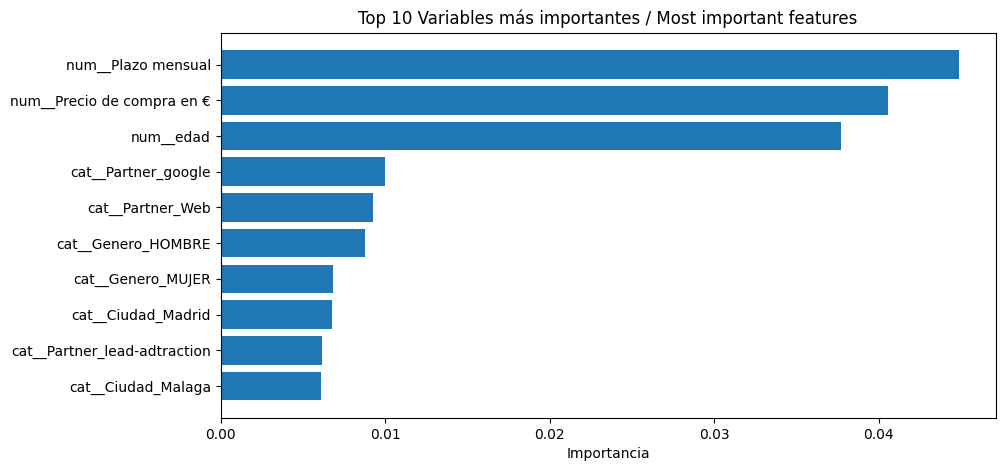

In [16]:
# ==================================================
# IMPORTANCIA DE VARIABLES / FEATURE IMPORTANCE
# ==================================================

# Accedemos al modelo Random Forest dentro del pipeline
modelo_rf = modelo.named_steps['classifier']

# Accedemos a los nombres de las variables después del preprocesamiento
# Esto es opcional, para vincular cada valor con su feature codificada
feature_names = modelo.named_steps['preprocessor'].get_feature_names_out()

# Creamos un DataFrame con la importancia
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.DataFrame({
    'feature': feature_names,
    'importance': modelo_rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# Mostramos las más importantes
print("\n Variables más importantes para el modelo:")
print(importancias.head(10))

# Gráfica
plt.figure(figsize=(10, 5))
plt.barh(importancias.head(10)['feature'], importancias.head(10)['importance'])
plt.xlabel("Importancia")
plt.title("Top 10 Variables más importantes / Most important features")
plt.gca().invert_yaxis()
plt.show()


🇪🇸 
Este gráfico muestra las variables más importantes según el modelo de Random Forest.
Es decir, aquellas que más influyen en la decisión final del modelo al clasificar el riesgo de impago en los diferentes buckets.

num__Plazo mensual, num__Precio de compra en € y num__edad son las variables numéricas con más peso.
Esto indica que el importe del plazo mensual y la edad del cliente están fuertemente correlacionados con el tipo de riesgo.

Algunas variables categóricas también tienen impacto, como:

cat__Partner_google (el canal comercial)

cat__Genero_HOMBRE (el género del cliente)

cat__Ciudad_Madrid (la ciudad del cliente)

Cuanto más alta es la barra, más relevante es esa variable para que el modelo tome su decisión.

🇬🇧 
This chart shows the most important features according to the trained Random Forest model.
These are the inputs that most influence the model’s decision when predicting the risk bucket.

The top 3 features are numeric: Monthly payment, Purchase price (€) and Customer age.
That means the model finds them highly informative for distinguishing between risk categories.

Some categorical features also stand out, such as:

Partner_google (commercial channel)

Gender_MALE

City_Madrid

The higher the bar, the more influential the feature in the model’s predictions.